# Análisis Avanzado — Dataset Amazon
## PA02 — Analítica de Datos | Grupo 05 | USS 2026-I

Completa los análisis exigidos por la guía (AG-07) que faltaban:
1. **Detección de outliers** (método IQR + boxplots)
2. **Análisis de dimensionalidad** (PCA + t-SNE)
3. **Comparación de modelos de predicción / estimación** sobre variable continua

Las gráficas se guardan en `/graficas` y un resumen en `resultados_avanzados.json`.


In [1]:
# Importación de librerías
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

sns.set_palette("husl")
RNG = 42
NUM = ["Quantity", "UnitPrice", "Discount", "Tax", "ShippingCost", "TotalAmount"]
resultados = {}

df = pd.read_csv("data/Amazon.csv")
print(f"{df.shape[0]:,} filas x {df.shape[1]} columnas")

100,000 filas x 20 columnas


## 1. Detección de valores atípicos (Outliers) — método IQR
Se considera atípico todo valor fuera de `[Q1 - 1.5*IQR , Q3 + 1.5*IQR]`.


In [2]:
outlier_info = {}
for col in NUM:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (df[col] < low) | (df[col] > high)
    outlier_info[col] = {"Q1": round(float(q1), 2), "Q3": round(float(q3), 2),
        "IQR": round(float(iqr), 2), "limite_inferior": round(float(low), 2),
        "limite_superior": round(float(high), 2), "n_outliers": int(mask.sum()),
        "pct_outliers": round(float(mask.mean() * 100), 2)}
    print(f"{col:13s}: {mask.sum():6,} outliers ({mask.mean()*100:5.2f}%)")
resultados["outliers"] = outlier_info

Quantity     :      0 outliers ( 0.00%)
UnitPrice    :      0 outliers ( 0.00%)
Discount     :  1,989 outliers ( 1.99%)
Tax          :  5,109 outliers ( 5.11%)
ShippingCost :      0 outliers ( 0.00%)
TotalAmount  :  1,360 outliers ( 1.36%)


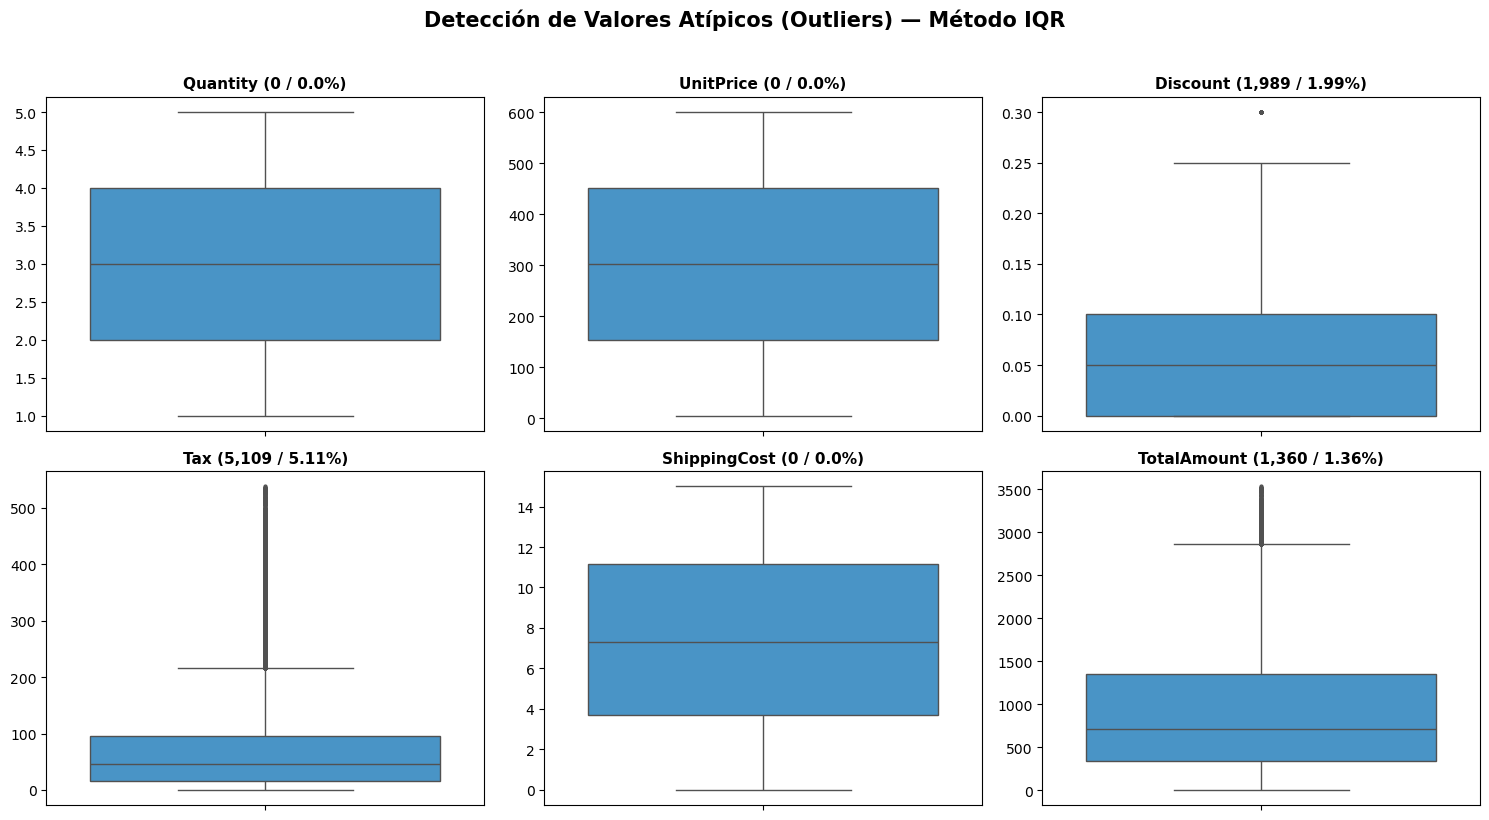

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), NUM):
    sns.boxplot(y=df[col], ax=ax, color="#3498db", fliersize=2)
    ax.set_title(f"{col} ({outlier_info[col]['n_outliers']:,} / {outlier_info[col]['pct_outliers']}%)",
                 fontsize=11, fontweight="bold")
    ax.set_ylabel("")
plt.suptitle("Detección de Valores Atípicos (Outliers) — Método IQR",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("graficas/grafica7_outliers.png", dpi=150, bbox_inches="tight")
plt.show()

**Decisión científica:** los atípicos de `Tax`, `Discount` y `TotalAmount` son pedidos grandes legítimos (no errores). No se eliminan para no sesgar el modelo; su efecto se controla con `StandardScaler`.


## 2. Análisis de dimensionalidad
Preprocesamiento (One-Hot + escalado). Target = pedido de alto/bajo valor (mediana de `TotalAmount`).


In [4]:
cat_cols = ["Category", "PaymentMethod", "Brand", "Country"]
drop_cols = ["OrderID", "OrderDate", "CustomerID", "CustomerName", "ProductID",
             "ProductName", "SellerID", "OrderStatus", "City", "State"]
dfm = df.drop(columns=[c for c in drop_cols if c in df.columns])
mediana = df["TotalAmount"].median()
target_valor = (df["TotalAmount"] > mediana).astype(int)
dfm = pd.get_dummies(dfm, columns=cat_cols, drop_first=False, dtype=int)
Xfull = dfm.drop(columns=["TotalAmount"]).select_dtypes(include=[np.number]).copy()
Xscaled = StandardScaler().fit_transform(Xfull)
print("Variables tras One-Hot:", Xscaled.shape[1])

Variables tras One-Hot: 32


### 2.1 PCA


PC1=5.58%  PC2=5.30%  comp>=90%: 25


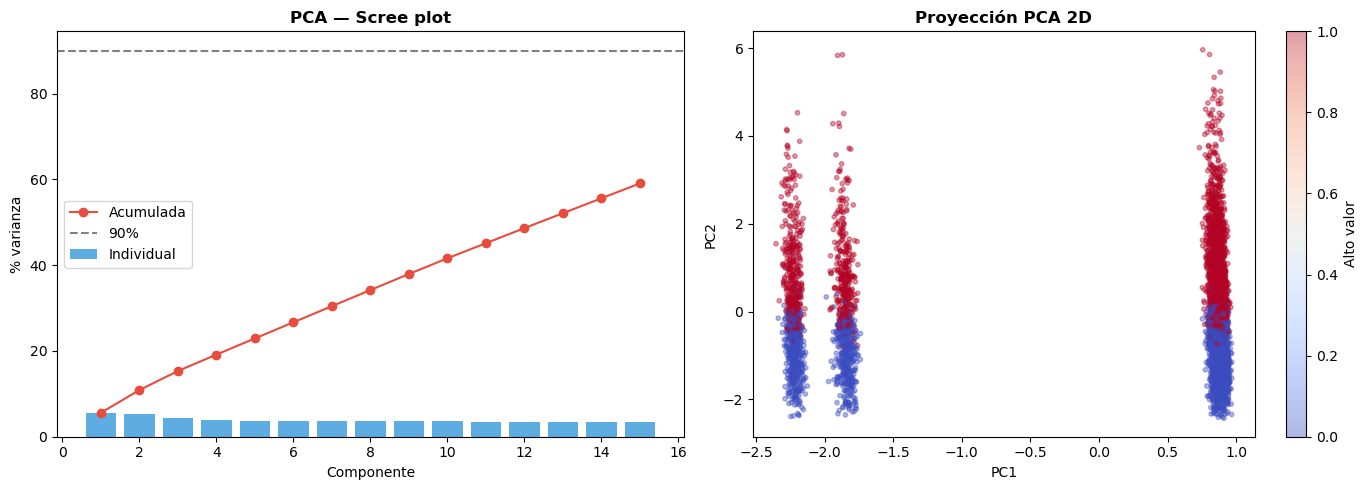

In [5]:
pca_full = PCA(random_state=RNG).fit(Xscaled)
cum_full = np.cumsum(pca_full.explained_variance_ratio_)
n90 = int(np.argmax(cum_full >= 0.90) + 1) if cum_full[-1] >= 0.90 else int(len(cum_full))
pca = PCA(n_components=min(15, Xscaled.shape[1]), random_state=RNG)
comps = pca.fit_transform(Xscaled)
evr = pca.explained_variance_ratio_
cum = np.cumsum(evr)
resultados["pca"] = {"n_features_original": int(Xscaled.shape[1]),
    "var_PC1": round(float(evr[0]) * 100, 2), "var_PC2": round(float(evr[1]) * 100, 2),
    "var_acumulada_2C": round(float(cum[1]) * 100, 2), "componentes_para_90pct": n90}
print(f"PC1={evr[0]*100:.2f}%  PC2={evr[1]*100:.2f}%  comp>=90%: {n90}")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].bar(range(1, len(evr) + 1), evr * 100, color="#3498db", alpha=0.8, label="Individual")
ax[0].plot(range(1, len(evr) + 1), cum * 100, "o-", color="#e74c3c", label="Acumulada")
ax[0].axhline(90, ls="--", color="gray", label="90%")
ax[0].set_xlabel("Componente"); ax[0].set_ylabel("% varianza")
ax[0].set_title("PCA — Scree plot", fontweight="bold"); ax[0].legend()
sub = np.random.RandomState(RNG).choice(len(comps), size=min(5000, len(comps)), replace=False)
sc = ax[1].scatter(comps[sub, 0], comps[sub, 1], c=target_valor.values[sub],
                   cmap="coolwarm", alpha=0.4, s=10)
ax[1].set_xlabel("PC1"); ax[1].set_ylabel("PC2")
ax[1].set_title("Proyección PCA 2D", fontweight="bold")
plt.colorbar(sc, ax=ax[1], label="Alto valor")
plt.tight_layout()
plt.savefig("graficas/grafica8_pca.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.2 t-SNE (muestra de 3 000, reducida con PCA a 10 comp.)


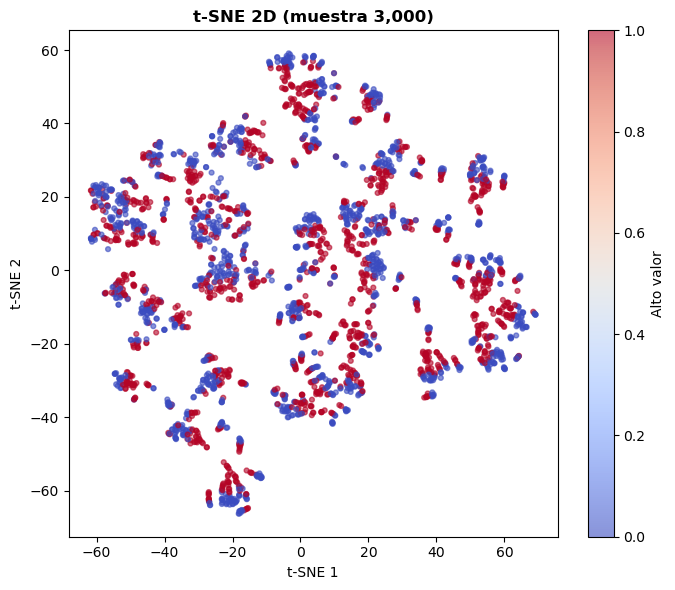

In [6]:
idx = np.random.RandomState(RNG).choice(len(Xscaled), size=3000, replace=False)
pca10 = PCA(n_components=10, random_state=RNG).fit_transform(Xscaled[idx])
emb = TSNE(n_components=2, random_state=RNG, perplexity=30, init="pca").fit_transform(pca10)
fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(emb[:, 0], emb[:, 1], c=target_valor.values[idx],
                cmap="coolwarm", alpha=0.6, s=12)
ax.set_title("t-SNE 2D (muestra 3,000)", fontweight="bold")
ax.set_xlabel("t-SNE 1"); ax.set_ylabel("t-SNE 2")
plt.colorbar(sc, ax=ax, label="Alto valor")
plt.tight_layout()
plt.savefig("graficas/grafica9_tsne.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Comparación de modelos de predicción / estimación (continuo)
Target = `TotalAmount`. Se **excluyen** `UnitPrice`, `Discount` y `Tax` porque `TotalAmount = Quantity*UnitPrice*(1-Discount)+Tax+ShippingCost` (relación determinística → evita *data leakage*).


In [7]:
feat_reg = ["Quantity", "ShippingCost"]
Xr = pd.get_dummies(df[feat_reg + cat_cols], columns=cat_cols, drop_first=False, dtype=int)
yr = df["TotalAmount"].values
n = min(25000, len(Xr))
si = np.random.RandomState(RNG).choice(len(Xr), size=n, replace=False)
Xr, yr = Xr.iloc[si].reset_index(drop=True), yr[si]
Xtr, Xte, ytr, yte = train_test_split(Xr, yr, test_size=0.2, random_state=RNG)
sc_r = StandardScaler()
Xtr_s = sc_r.fit_transform(Xtr)
Xte_s = sc_r.transform(Xte)

regs = {"Regresión Lineal": (LinearRegression(), False),
    "Random Forest Regressor": (RandomForestRegressor(n_estimators=120, max_depth=14,
                                                      random_state=RNG, n_jobs=-1), False),
    "SVR (RBF)": (SVR(C=10, gamma="scale"), True),
    "KNN Regressor": (KNeighborsRegressor(n_neighbors=15), True)}
filas = []
for nombre, (modelo, esc) in regs.items():
    Xt, Xv = (Xtr_s, Xte_s) if esc else (Xtr.values, Xte.values)
    modelo.fit(Xt, ytr)
    pred = modelo.predict(Xv)
    r2 = r2_score(yte, pred)
    mae = mean_absolute_error(yte, pred)
    rmse = float(np.sqrt(mean_squared_error(yte, pred)))
    filas.append({"Modelo": nombre, "R2": round(r2, 4), "MAE": round(mae, 2), "RMSE": round(rmse, 2)})
    print(f"{nombre:26s} R2={r2:6.4f}  MAE={mae:8.2f}  RMSE={rmse:8.2f}")
tabla = pd.DataFrame(filas).sort_values("R2", ascending=False).reset_index(drop=True)
resultados["regresion"] = {"target": "TotalAmount",
    "features_excluidas_por_leakage": ["UnitPrice", "Discount", "Tax"],
    "n_muestra": int(n), "tabla": filas, "mejor_modelo": tabla.iloc[0]["Modelo"]}
tabla

Regresión Lineal           R2=0.3410  MAE=  461.98  RMSE=  591.12


Random Forest Regressor    R2=0.3245  MAE=  465.51  RMSE=  598.43


SVR (RBF)                  R2=0.2919  MAE=  473.46  RMSE=  612.75


KNN Regressor              R2=0.2029  MAE=  513.31  RMSE=  650.08


,Modelo,R2,MAE,RMSE
0,Regresión Lineal,0.3410,461.98,591.12
1,Random Forest Regressor,0.3245,465.51,598.43
2,SVR (RBF),0.2919,473.46,612.75
3,KNN Regressor,0.2029,513.31,650.08


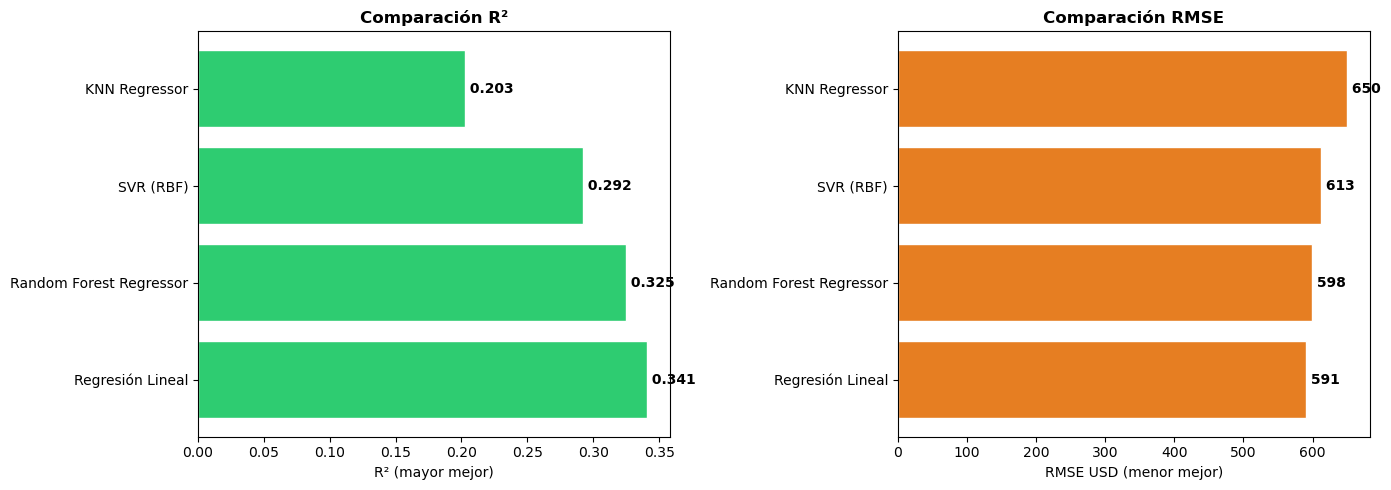

Resumen guardado en resultados_avanzados.json


In [8]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].barh(tabla["Modelo"], tabla["R2"], color="#2ecc71", edgecolor="white")
for i, v in enumerate(tabla["R2"]):
    ax[0].text(v, i, f" {v:.3f}", va="center", fontweight="bold")
ax[0].set_title("Comparación R²", fontweight="bold"); ax[0].set_xlabel("R² (mayor mejor)")
ax[1].barh(tabla["Modelo"], tabla["RMSE"], color="#e67e22", edgecolor="white")
for i, v in enumerate(tabla["RMSE"]):
    ax[1].text(v, i, f" {v:.0f}", va="center", fontweight="bold")
ax[1].set_title("Comparación RMSE", fontweight="bold"); ax[1].set_xlabel("RMSE USD (menor mejor)")
plt.tight_layout()
plt.savefig("graficas/grafica10_regresion.png", dpi=150, bbox_inches="tight")
plt.show()

with open("resultados_avanzados.json", "w", encoding="utf-8") as f:
    json.dump(resultados, f, indent=2, ensure_ascii=False)
print("Resumen guardado en resultados_avanzados.json")